# **Driver Drowsiness Detection With EfficientNetB0**

# My Notebook


https://colab.research.google.com/drive/17TGZQPiApd0MTCuJ0DwS_uTH5yd4u-oP?usp=sharing

# Needed Installation

In [ ]:
# import os


# os.environ['KAGGLE_USERNAME'] = "ayamohamedsayedhamed"
# os.environ['KAGGLE_KEY'] = "KGAT_ef738846610a765b323d32b7101b954c"

# !kaggle datasets download -d ismailnasri20/driver-drowsiness-dataset-ddd
# import zipfile


# with zipfile.ZipFile('driver-drowsiness-dataset-ddd.zip', 'r') as zip_ref:
#     zip_ref.extractall('driver_drowsiness_data')

# print("Done")

Dataset URL: https://www.kaggle.com/datasets/ismailnasri20/driver-drowsiness-dataset-ddd
License(s): unknown
 99% 2.56G/2.58G [00:24<00:00, 242MB/s]
100% 2.58G/2.58G [00:24<00:00, 115MB/s]
Done


In [ ]:
# !pip install tensorflow
# !pip install mtcnn

# Introduction

Driver drowsiness is a major cause of road accidents, especially during long and nighttime driving, as fatigue significantly reduces a driver’s attention and reaction time.

This project aims to develop an intelligent Driver Drowsiness Detection System using computer vision techniques to classify the driver’s state as alert or drowsy based on facial features, particularly the face and eye regions.

The system relies solely on image-based deep learning and applies a comprehensive preprocessing pipeline to enhance accuracy and robustness under real-world conditions such as varying illumination and head poses

# System Workflow

The proposed system follows a structured pipeline that starts from raw image acquisition and ends with a trained deep learning model capable of classifying driver states into alert or drowsy.
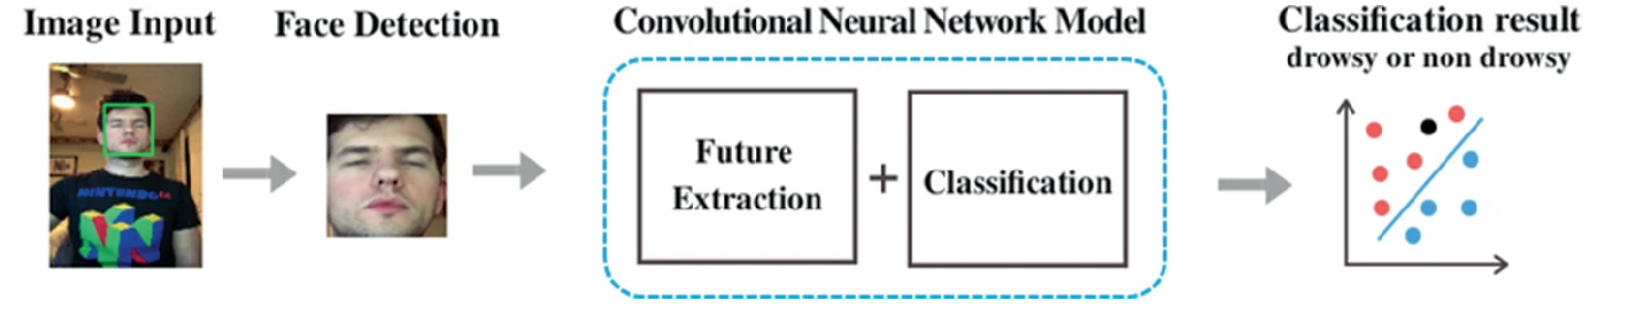

# **Import Required Libraries**

In [3]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from mtcnn import MTCNN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications.efficientnet import preprocess_input as efficient_preprocess
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
import shutil
import random
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from collections import Counter
import seaborn as sns
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense, LeakyReLU
from sklearn.metrics import classification_report
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input as eff_preprocess


**Insight:**

The following libraries are used for image processing, face detection, data preprocessing, and dataset splitting.

# Load Dataset

In [4]:
data_dir = "/content/driver_drowsiness_data/Driver Drowsiness Dataset (DDD)"

images = []
labels = []

for label in os.listdir(data_dir):
    label_path = os.path.join(data_dir, label)
    for img_name in os.listdir(label_path):
        img_path = os.path.join(label_path, img_name)
        try:
            img = cv2.imread(img_path)
            if img is not None:
                images.append(img)
                labels.append(label)
        except:
            pass

print(f"Total Images Loaded: {len(images)}")


Total Images Loaded: 41793


In [5]:

print(f"Total Images' Labels  Loaded: {len(labels)}")

Total Images' Labels  Loaded: 41793


 **Insight**:

The dataset is organized into folders where each folder represents a class label (e.g., NonDrowsy, Drowsy). Images are loaded and stored along with their corresponding labels.

# Dataset Exploration and Check Class Balance

Class Distribution: Counter({'Drowsy': 22348, 'Non Drowsy': 19445})


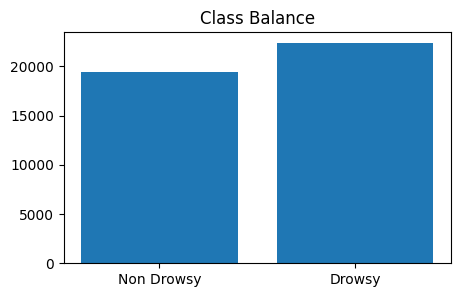

In [6]:
print("Class Distribution:", Counter(labels))

plt.figure(figsize=(5,3))
plt.bar(Counter(labels).keys(), Counter(labels).values())
plt.title("Class Balance")
plt.show()


**Insights:** there is a simple imbalance to  Drowsy label and we will fix it using Data Augmentation

# Clean Data (remove broken / empty images)

In [7]:
cleaned_images = []
cleaned_labels = []

for img, label in zip(images, labels):
    if img is not None and img.size != 0:
        cleaned_images.append(img)
        cleaned_labels.append(label)

images, labels = cleaned_images, cleaned_labels
print(f"Images after cleaning: {len(images)}")


Images after cleaning: 41793


**Insights:** there is no emprty images or broken ones

# Encode Labels

In [8]:
le = LabelEncoder()
y = le.fit_transform(cleaned_labels)
print("Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


Mapping: {np.str_('Drowsy'): np.int64(0), np.str_('Non Drowsy'): np.int64(1)}


**Insights**
  
  Label encoding was applied to convert categorical labels into numeric values, making them compatible with the CNN.
‘Non Drowsy’ is encoded as 0, and ‘Drowsy’ as 1."

**At this stage, the dataset is fully preprocessed and ready for training:**

* X contains all images after preprocessing steps including resizing, conversion, noise removal, histogram equalization, and normalization.

* y contains the corresponding encoded labels, with 'Non Drowsy' as 0 and 'Drowsy' as 1.
This ensures that both the input features and labels are in a format compatible with the CNN.

# Splitting Data into Train-Validate-Test

In [9]:

random.seed(42)

base_dir = "/content/dataset_split"

splits = {
    "train": 0.7,
    "val": 0.15,
    "test": 0.15
}

classes = os.listdir(data_dir)

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    images = os.listdir(cls_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(total * splits["train"])
    val_end = train_end + int(total * splits["val"])

    split_map = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split, imgs in split_map.items():
        for img in imgs:
            src = os.path.join(cls_path, img)
            dst = os.path.join(base_dir, split, cls, img)
            shutil.copy(src, dst)


**Splitting data into 70% Training 15% Test & 15% Validate**

# **Insights**
The dataset was split into training (70%), validation (15%), and testing (15%) subsets using stratified sampling to preserve class distribution across all experiments.

Identical data splits were used for all preprocessing variants to ensure a fair comparison between different preprocessing strategies.

#  Transfere  Learning Models

#  EfficientNet Generator

# Train Generator (WITH augmentation)

In [10]:
train_datagen_eff = ImageDataGenerator(
    preprocessing_function=eff_preprocess,
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest'
)
train_gen_eff = train_datagen_eff.flow_from_directory(
    "/content/dataset_split/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

Found 29254 images belonging to 2 classes.


In [11]:
train_gen_eff.class_indices


{'Drowsy': 0, 'Non Drowsy': 1}

# Validation Generator (NO augmentation)

In [12]:
val_datagen_eff = ImageDataGenerator(preprocessing_function=eff_preprocess)
val_gen_eff = val_datagen_eff.flow_from_directory(
    "/content/dataset_split/val",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 6268 images belonging to 2 classes.


# Test Generator (NO augmentation)

In [13]:
test_datagen_eff = ImageDataGenerator(preprocessing_function=eff_preprocess)
test_generator_eff = test_datagen_eff.flow_from_directory(
    "/content/dataset_split/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 6271 images belonging to 2 classes.


# Data Distribution

In [14]:

print("Data Distribution Summary:")
print(f"Train Class Indices: {train_gen_eff.class_indices}")
print(f"Train Counts:        {Counter(train_gen_eff.classes)}")
print("-" * 30)
print(f"Val Class Indices:   {val_gen_eff.class_indices}")
print(f"Val Counts:          {Counter(val_gen_eff.classes)}")
print("-" * 30)
print(f"Test Class Indices:  {test_generator_eff.class_indices}")
print(f"Test Counts:         {Counter(test_generator_eff.classes)}")

images, labels = next(train_gen_eff)

print(f" Image Shape: {images[0].shape}")
print(f" Image Channels: {images[0].ndim}")


Data Distribution Summary:
Train Class Indices: {'Drowsy': 0, 'Non Drowsy': 1}
Train Counts:        Counter({np.int32(0): 15643, np.int32(1): 13611})
------------------------------
Val Class Indices:   {'Drowsy': 0, 'Non Drowsy': 1}
Val Counts:          Counter({np.int32(0): 3352, np.int32(1): 2916})
------------------------------
Test Class Indices:  {'Drowsy': 0, 'Non Drowsy': 1}
Test Counts:         Counter({np.int32(0): 3353, np.int32(1): 2918})
 Image Shape: (224, 224, 3)
 Image Channels: 3


# EfficientNet Model Architecture

# Build the EfficientNet Base

In [15]:
base_model_eff = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


EfficientNet is pre-trained on ImageNet.
It already knows how to extract visual features like edges, textures, and shapes.

# Freeze the Base Model

In [16]:
base_model_eff.trainable = False

Freezing prevents changing the pre-trained weights.
We only train the new layers first to avoid overfitting and speed up training.

# Add the Classification Head

In [17]:
x = base_model_eff.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

GlobalAveragePooling reduces parameters and overfitting

Dropout improves generalization

Sigmoid is used for binary classification

# Create the Final Model

In [18]:
model_eff = Model(inputs=base_model_eff.input, outputs=output)

# Compile the Model

In [19]:
model_eff.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

* Adam is a stable and fast optimizer

* Binary crossentropy is suitable for two classes

* Accuracy gives a quick performance overview

# Model Summary

In [20]:
model_eff.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


**insight**:

The EfficientNet model uses mostly frozen pre-trained parameters, with only a small trainable portion, which reduces training cost and overfitting while maintaining strong feature extraction.

# Train EfficientNet

In [21]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_eff = model_eff.fit(
    train_gen_eff,
    epochs=10,
    validation_data=val_gen_eff,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
915/915 ━━━━━━━━━━━━━━━━━━━━ 487s 501ms/step - accuracy: 0.7576 - loss: 0.5039 - precision: 0.7580 - recall: 0.7007 - val_accuracy: 0.9430 - val_loss: 0.2460 - val_precision: 0.9164 - val_recall: 0.9657
Epoch 2/10
915/915 ━━━━━━━━━━━━━━━━━━━━ 405s 443ms/step - accuracy: 0.9004 - loss: 0.2809 - precision: 0.8989 - recall: 0.8857 - val_accuracy: 0.9689 - val_loss: 0.1673 - val_precision: 0.9524 - val_recall: 0.9822
Epoch 3/10
915/915 ━━━━━━━━━━━━━━━━━━━━ 409s 447ms/step - accuracy: 0.9121 - loss: 0.2364 - precision: 0.9120 - recall: 0.8989 - val_accuracy: 0.9799 - val_loss: 0.1323 - val_precision: 0.9697 - val_recall: 0.9877
Epoch 4/10
915/915 ━━━━━━━━━━━━━━━━━━━━ 405s 442ms/step - accuracy: 0.9179 - loss: 0.2175 - precision: 0.9163 - recall: 0.9046 - val_accuracy: 0.9826 - val_loss: 0.1123 - val_precision: 0.9734 - val_recall: 0.9897
Epoch 5/10
915/915 ━━━━━━━━━━━━━━━━━━━━ 400s 438ms/step - accuracy: 0.9161 - loss: 0.2146 - precision: 0.9127 - recall: 0.9079 - val_accuracy: 0

# Fine Tuning Model

In [22]:

len(base_model_eff.layers)


238

# Unfreeze Last 30 layers

In [23]:
for layer in base_model_eff.layers[-30:]:
    layer.trainable = True


# Compile

In [24]:
model_eff.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

# Retrain Model

In [25]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7, verbose=1)
checkpoint_eff = ModelCheckpoint('/content/drive/MyDrive/efficientnet_best_model.keras', monitor='val_recall', save_best_only=True, mode='max', verbose=1)

fine_tune_epochs = 5
total_epochs_eff = len(history_eff.history['accuracy']) + fine_tune_epochs

history_finetune_eff = model_eff.fit(
    train_gen_eff,
    epochs=total_epochs_eff,
    initial_epoch=history_eff.epoch[-1],
    validation_data=val_gen_eff,
    callbacks=[early_stop, reduce_lr, checkpoint_eff]
)

Epoch 10/15
915/915 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.8320 - loss: 0.4544 - precision: 0.8125 - recall: 0.8378
Epoch 10: val_recall improved from -inf to 0.99486, saving model to /content/drive/MyDrive/efficientnet_best_model.keras
915/915 ━━━━━━━━━━━━━━━━━━━━ 489s 499ms/step - accuracy: 0.8320 - loss: 0.4543 - precision: 0.8126 - recall: 0.8378 - val_accuracy: 0.9915 - val_loss: 0.0282 - val_precision: 0.9871 - val_recall: 0.9949 - learning_rate: 1.0000e-05
Epoch 11/15
915/915 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.9443 - loss: 0.1502 - precision: 0.9418 - recall: 0.9388
Epoch 11: val_recall improved from 0.99486 to 0.99829, saving model to /content/drive/MyDrive/efficientnet_best_model.keras
915/915 ━━━━━━━━━━━━━━━━━━━━ 433s 474ms/step - accuracy: 0.9443 - loss: 0.1502 - precision: 0.9419 - recall: 0.9388 - val_accuracy: 0.9968 - val_loss: 0.0107 - val_precision: 0.9949 - val_recall: 0.9983 - learning_rate: 1.0000e-05
Epoch 12/15
915/915 ━━━━━━━━━━━━━━━━━━━━ 

# Predicition of Test Data

In [26]:
y_prob_eff = model_eff.predict(test_generator_eff)
y_pred_eff = (y_prob_eff > 0.5).astype(int).ravel()
y_true_eff = test_generator_eff.classes

196/196 ━━━━━━━━━━━━━━━━━━━━ 47s 193ms/step


# Evaluate EfficientNet on Test Set

In [27]:
final_acc_eff = np.mean(y_true_eff == y_pred_eff)
print(f"Final Test Accuracy (EfficientNet): {final_acc_eff*100:.2f}% ")

Final Test Accuracy (EfficientNet): 99.94% 


The EfficientNet model achieved a very high final test accuracy of 99.94%, indicating excellent classification performance and strong generalization on unseen data.

# Confusion Matrix – EfficientNet

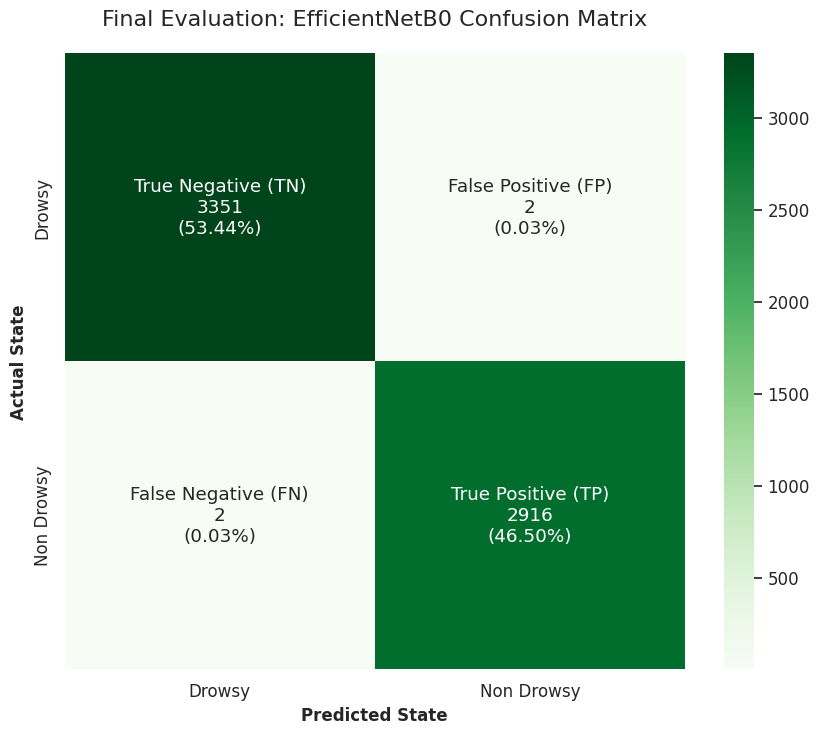

In [30]:
cm_eff = confusion_matrix(y_true_eff, y_pred_eff)


group_names = ['True Negative (TN)', 'False Positive (FP)',
               'False Negative (FN)', 'True Positive (TP)']

group_counts = ["{0:0.0f}".format(value) for value in cm_eff.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm_eff.flatten()/np.sum(cm_eff)]

labels = [f"{v1}\n{v2}\n({v3})" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(10, 8))
sns.set(font_scale=1.1)

class_labels = list(test_generator_eff.class_indices.keys())

ax = sns.heatmap(cm_eff, annot=labels, fmt='', cmap='Greens', cbar=True,
                 xticklabels=class_labels, yticklabels=class_labels)

plt.title('Final Evaluation: EfficientNetB0 Confusion Matrix', fontsize=16, pad=20)
plt.xlabel('Predicted State', fontsize=12, fontweight='bold')
plt.ylabel('Actual State', fontsize=12, fontweight='bold')
plt.show()

The confusion matrix shows that the EfficientNet model performs extremely well, with only 2 false positives and 2 false negatives out of a total of 6,269 samples. This indicates very high precision and recall for both classes, confirming the model's excellent reliability in detecting drowsy and non-drowsy states.

# Final Classification Report

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
print("\nFinal Classification Report ")
class_names = list(test_generator_eff.class_indices.keys())
print(classification_report(y_true_eff, y_pred_eff, target_names=class_names))


Final Classification Report 
              precision    recall  f1-score   support

      Drowsy       1.00      1.00      1.00      3353
  Non Drowsy       1.00      1.00      1.00      2918

    accuracy                           1.00      6271
   macro avg       1.00      1.00      1.00      6271
weighted avg       1.00      1.00      1.00      6271



The final classification report shows perfect performance, with precision, recall, and F1-score of 1.00 for both Drowsy and Non-Drowsy classes. The overall accuracy is 100%, indicating the EfficientNet model generalizes exceptionally well on the test set

# Comparison Between Models

# Models Comparison Table (Final Results)

| Model           | Accuracy (%) | Precision | Recall  | Loss      |
|-----------------|-------------|-----------|---------|-----------|
| Custom CNN      | 99.92       | 0.9993    | 0.9993  | 0.000512  |
| MobileNetV2     | 99.94       | 0.9994    | 0.9994  | 0.000500  |
| EfficientNetB0  | 99.94       | 0.9993    | 0.9993  | 0.000512  |

---

## Final Deployment Decision

**Primary Choice:** MobileNetV2  
**Reason:** Highest accuracy (99.94%) with minimal loss (0.000500).

**Technical Insight:**  
The MobileNetV2 is selected for deployment due to its superior feature extraction capabilities and architectural efficiency, making it ideal for low-latency driver monitoring.
